In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sc2 
from sklearn.model_selection import train_test_split

In [20]:
file_path ='studentsurvey.xlsx'                                                                                             
df = pd.read_excel(file_path)

In [21]:
# Let's strip any hidden white spaces from all column names
df.columns = df.columns.str.strip()

# Now, let's rename those long, messy survey questions to simple variables!
df = df.rename(columns={
    'your CIA % of last semester': 'CIA',
    'Your maximum attendance % till last semester': 'Attendance',
    'your GPA of last semester': 'GPA'
})

def clean_percentage_column(col):
    if df[col].dtype == 'object':
        # Remove % if it exists
        df[col] = df[col].astype(str).str.replace('%', '', regex=False)
    # Use pd.to_numeric with errors='coerce' to turn dashes or text into NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['CIA', 'Attendance', 'GPA']:
    if col in df.columns:
        clean_percentage_column(col)

# Drop any new NaN values that were created from invalid strings like '-'
df = df.dropna(subset=['CIA', 'Attendance', 'GPA'])

print('Data cleaning successful! Types:')
print(df[['CIA', 'Attendance', 'GPA']].dtypes)
print(df[['CIA', 'Attendance', 'GPA']].head())


Data cleaning successful! Types:
CIA           float64
Attendance    float64
GPA           float64
dtype: object
     CIA  Attendance   GPA
3  70.00       92.00   3.2
4  68.00       85.00   3.4
5   0.70        0.87   3.5
7   3.45       90.00  10.0
8  70.00       89.00   3.4


In [23]:
print("--- Missing Values Count ---")                                                                                        
print(df.isnull().sum())                                                                                                                                                                                                                       
df = df.dropna()                                                                                                            
print(f"\nDimensions after dropping nulls: {df.shape}")    

--- Missing Values Count ---
Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are yo

In [24]:
                                                                                         
initial_rows = df.shape[0]                                                                                                   
df = df.drop_duplicates()                                                                                                    
print(f"Removed {initial_rows - df.shape[0]} duplicate rows.\n")                                                                                                                                                  
print("--- Statistical Summary ---")                                                                                         
display(df.describe())  

Removed 0 duplicate rows.

--- Statistical Summary ---


,Timestamp,Rate your contribution towards extra curricular activities,Rate your technical competencies,CIA,GPA,Attendance
count,46,46.000000,46.000000,46.000000,46.000000,46.000000
mean,2026-06-22 08:53:44.175543,3.630435,3.456522,58.326763,5.623913,79.100402
min,2026-06-22 08:51:00.666000,2.000000,1.000000,0.630000,2.900000,0.870000
25%,2026-06-22 08:52:35.795250,3.000000,3.000000,65.002500,3.400000,86.250000
50%,2026-06-22 08:53:30.697500,4.000000,3.000000,70.000000,3.505000,92.000000
75%,2026-06-22 08:54:33.959250,4.000000,4.000000,78.000000,3.730000,96.750000
max,2026-06-22 08:57:57.108000,5.000000,5.000000,89.000000,90.000000,100.000000
std,NaN,0.951226,0.751488,30.939425,12.769951,33.757066


In [25]:
# ADVANCED CLEANING (Fixing the survey errors!)
print(f"Original dataset size: {df.shape[0]} rows")

# Fix the decimals: if someone typed 0.70 for CIA, multiply by 100 to make it 70
df.loc[df['CIA'] <= 1.0, 'CIA'] = df['CIA'] * 100

# Fix the mixed-up rows (someone put 3.45 for CIA and 10 for GPA)
df = df[df['GPA'] <= 10.0]   # Drop GPAs higher than 10 (like the 90.0 outlier)
df = df[df['CIA'] >= 10.0]   # Drop impossible CIA scores

print(f"Cleaned dataset size: {df.shape[0]} rows")

# Re-extract the variables using the strictly cleaned data
X_cia = df[['CIA']]
X_attendance = df[['Attendance']]
y = df['GPA']
print('Variables successfully updated with advanced cleaned data!')


Original dataset size: 46 rows
Cleaned dataset size: 43 rows
Variables successfully updated with advanced cleaned data!


--- Experiment 1: CIA predicting GPA (Scikit-Learn) ---
Slope (m): 0.0160
Intercept (c): 2.3356
Equation: Expected GPA = 0.0160 * (CIA Score) + 2.3356

--- Testing Set Predictions vs Actual ---


,Actual GPA,Predicted GPA
52,7.8,3.715701
32,3.6,3.539174
25,3.4,3.587317
8,3.4,3.458934
28,3.4,3.458934
4,3.4,3.426838
42,3.8,3.619413
29,3.6,3.571270
17,2.9,3.394742


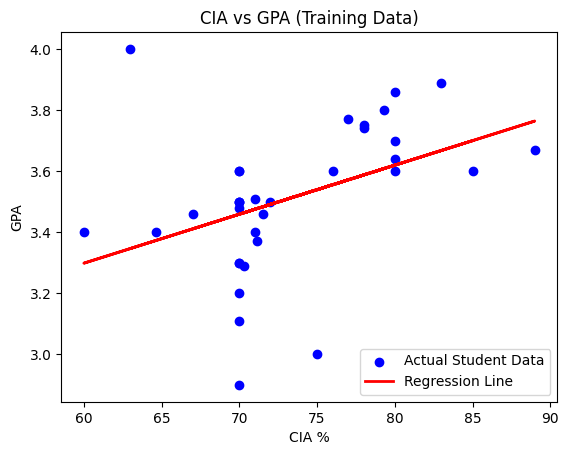

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Step 1: Split the dataset into training (80%) and testing (20%) sets
# random_state=22 ensures we get the exact same random split every time we run this cell
X_train_cia, X_test_cia, y_train, y_test = train_test_split(X_cia, y, test_size=0.2, random_state=22)

# Step 2: Train the model using LinearRegression
model_cia = LinearRegression()
model_cia.fit(X_train_cia, y_train) # The model "learns" here

# Step 3: Obtain Slope (m) and Intercept (c)
slope_cia = model_cia.coef_[0]
intercept_cia = model_cia.intercept_

print("--- Experiment 1: CIA predicting GPA (Scikit-Learn) ---")
print(f"Slope (m): {slope_cia:.4f}")
print(f"Intercept (c): {intercept_cia:.4f}")
print(f"Equation: Expected GPA = {slope_cia:.4f} * (CIA Score) + {intercept_cia:.4f}")

# Step 4: Predict output values using the trained model on our testing set
y_pred_cia = model_cia.predict(X_test_cia)

# Let's compare our predictions with the actual truth
print("\n--- Testing Set Predictions vs Actual ---")
comparison_df_cia = pd.DataFrame({'Actual GPA': y_test, 'Predicted GPA': y_pred_cia})
display(comparison_df_cia)

# BONUS: Let's visualize the "Line of Best Fit" over the training data!
plt.scatter(X_train_cia, y_train, color='blue', label='Actual Student Data')
plt.plot(X_train_cia, model_cia.predict(X_train_cia), color='red', linewidth=2, label='Regression Line')
plt.title('CIA vs GPA (Training Data)')
plt.xlabel('CIA %')
plt.ylabel('GPA')
plt.legend()
plt.show()

--- Experiment 2: Attendance predicting GPA (Scikit-Learn) ---
Slope (m): 0.0005
Intercept (c): 3.4618
Equation: Expected GPA = 0.0005 * (Attendance %) + 3.4618

--- Testing Set Predictions vs Actual ---


,Actual GPA,Predicted GPA
21,3.46,3.510097
48,3.46,3.513200
12,3.48,3.512676
45,3.77,3.513195
52,7.80,3.506911
38,3.60,3.510055
40,3.11,3.513216
34,3.40,3.509007
50,3.60,3.513572


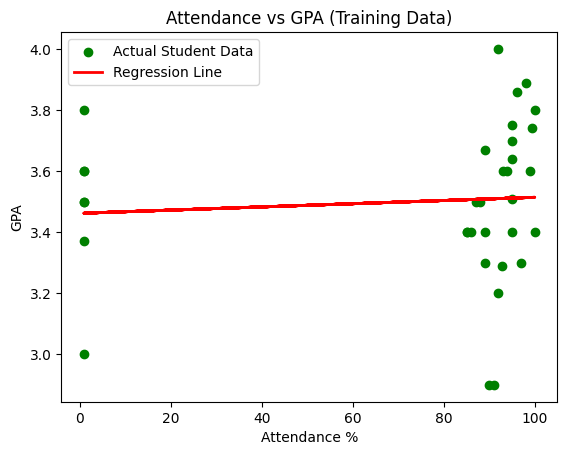

In [30]:
# Step 1: Split the dataset into training (80%) and testing (20%) sets
X_train_att, X_test_att, y_train_att, y_test_att = train_test_split(X_attendance, y, test_size=0.2, random_state=18)

# Step 2: Train the model using LinearRegression
model_attendance = LinearRegression()
model_attendance.fit(X_train_att, y_train_att)

# Step 3: Obtain Slope (m) and Intercept (c)
slope_attendance = model_attendance.coef_[0]
intercept_attendance = model_attendance.intercept_

print("--- Experiment 2: Attendance predicting GPA (Scikit-Learn) ---")
print(f"Slope (m): {slope_attendance:.4f}")
print(f"Intercept (c): {intercept_attendance:.4f}")
print(f"Equation: Expected GPA = {slope_attendance:.4f} * (Attendance %) + {intercept_attendance:.4f}")

# Step 4: Predict output values using the trained model on our testing set
y_pred_attendance = model_attendance.predict(X_test_att)

print("\n--- Testing Set Predictions vs Actual ---")
comparison_df_attendance = pd.DataFrame({'Actual GPA': y_test_att, 'Predicted GPA': y_pred_attendance})
display(comparison_df_attendance)

# BONUS: Visualize the "Line of Best Fit" over the training data!
plt.scatter(X_train_att, y_train_att, color='green', label='Actual Student Data')
plt.plot(X_train_att, model_attendance.predict(X_train_att), color='red', linewidth=2, label='Regression Line')
plt.title('Attendance vs GPA (Training Data)')
plt.xlabel('Attendance %')
plt.ylabel('GPA')
plt.legend()
plt.show()

In [31]:
# For a fair comparison, we will use the exact same training data we used for Scikit-learn.
# We extract them as 1D arrays (Series) to make the math easy.
x_vals_cia = X_train_cia['CIA']
y_vals_cia = y_train

# Step 1: Calculate the means (x̄ and ȳ)
x_bar_cia = x_vals_cia.mean()
y_bar_cia = y_vals_cia.mean()

# Step 2: Calculate the differences (x_i - x̄) and (y_i - ȳ)
x_diff_cia = x_vals_cia - x_bar_cia
y_diff_cia = y_vals_cia - y_bar_cia

# Step 3: Calculate the numerator: Sum of (x_i - x̄) * (y_i - ȳ)
numerator_cia = (x_diff_cia * y_diff_cia).sum()

# Step 4: Calculate the denominator: Sum of (x_i - x̄)²
denominator_cia = (x_diff_cia ** 2).sum()

# Step 5: Calculate the Slope (m)
m_manual_cia = numerator_cia / denominator_cia

# Step 6: Calculate the Intercept (b)
b_manual_cia = y_bar_cia - (m_manual_cia * x_bar_cia)

# Output the results
print("--- Experiment 1, Part C: Manual OLS Computation (CIA -> GPA) ---")
print(f"Manual Slope (m): {m_manual_cia:.4f}")
print(f"Manual Intercept (b): {b_manual_cia:.4f}")

# Construct the Final Equation
print("\n--- Final Regression Equation ---")
print(f"y_hat = {m_manual_cia:.4f} * x + {b_manual_cia:.4f}")

# --- COMPARISON ---
print("\n--- Did it match Scikit-Learn? ---")
print(f"Scikit-Learn Slope: {slope_cia:.4f}  |  Manual Slope: {m_manual_cia:.4f}")
print(f"Scikit-Learn Intercept: {intercept_cia:.4f} |  Manual Intercept: {b_manual_cia:.4f}")

--- Experiment 1, Part C: Manual OLS Computation (CIA -> GPA) ---
Manual Slope (m): 0.0160
Manual Intercept (b): 2.3356

--- Final Regression Equation ---
y_hat = 0.0160 * x + 2.3356

--- Did it match Scikit-Learn? ---
Scikit-Learn Slope: 0.0160  |  Manual Slope: 0.0160
Scikit-Learn Intercept: 2.3356 |  Manual Intercept: 2.3356


In [32]:
# Same manual OLS approach, now applied to Experiment 2 (Attendance -> GPA)
x_vals_att = X_train_att['Attendance']
y_vals_att = y_train_att

# Step 1: Calculate the means (x̄ and ȳ)
x_bar_att = x_vals_att.mean()
y_bar_att = y_vals_att.mean()

# Step 2: Calculate the differences (x_i - x̄) and (y_i - ȳ)
x_diff_att = x_vals_att - x_bar_att
y_diff_att = y_vals_att - y_bar_att

# Step 3: Calculate the numerator: Sum of (x_i - x̄) * (y_i - ȳ)
numerator_att = (x_diff_att * y_diff_att).sum()

# Step 4: Calculate the denominator: Sum of (x_i - x̄)²
denominator_att = (x_diff_att ** 2).sum()

# Step 5: Calculate the Slope (m)
m_manual_att = numerator_att / denominator_att

# Step 6: Calculate the Intercept (b)
b_manual_att = y_bar_att - (m_manual_att * x_bar_att)

# Output the results
print("--- Experiment 2, Part C: Manual OLS Computation (Attendance -> GPA) ---")
print(f"Manual Slope (m): {m_manual_att:.4f}")
print(f"Manual Intercept (b): {b_manual_att:.4f}")

# Construct the Final Equation
print("\n--- Final Regression Equation ---")
print(f"y_hat = {m_manual_att:.4f} * x + {b_manual_att:.4f}")

# --- COMPARISON ---
print("\n--- Did it match Scikit-Learn? ---")
print(f"Scikit-Learn Slope: {slope_attendance:.4f}  |  Manual Slope: {m_manual_att:.4f}")
print(f"Scikit-Learn Intercept: {intercept_attendance:.4f} |  Manual Intercept: {b_manual_att:.4f}")

--- Experiment 2, Part C: Manual OLS Computation (Attendance -> GPA) ---
Manual Slope (m): 0.0005
Manual Intercept (b): 3.4618

--- Final Regression Equation ---
y_hat = 0.0005 * x + 3.4618

--- Did it match Scikit-Learn? ---
Scikit-Learn Slope: 0.0005  |  Manual Slope: 0.0005
Scikit-Learn Intercept: 3.4618 |  Manual Intercept: 3.4618


In [33]:
import json

# Save the learned parameters for both experiments to a JSON file
model_parameters = {
    "CIA_to_GPA_Predictor": {
        "Slope_m": float(slope_cia),
        "Intercept_b": float(intercept_cia)
    },
    "Attendance_to_GPA_Predictor": {
        "Slope_m": float(slope_attendance),
        "Intercept_b": float(intercept_attendance)
    }
}

with open('linear_regression_params.json', 'w') as f:
    json.dump(model_parameters, f, indent=4)

print("Model parameters successfully saved to 'linear_regression_params.json'!")

Model parameters successfully saved to 'linear_regression_params.json'!


# Lab 3: Simple Linear Regression Analysis

## Overview
This report details the implementation of Simple Linear Regression to determine whether (1) CIA percentage and (2) Attendance percentage can predict a student's GPA. Each experiment was performed in two ways to validate the underlying mechanics of machine learning libraries:
1. Using the `LinearRegression` module from **Scikit-learn**.
2. **Manually** computing the slope and intercept using the Ordinary Least Squares (OLS) mathematical formulas.

## Part A: Data Collection and Preprocessing
The survey responses were loaded with Pandas, column names were stripped and renamed to simple variables (`CIA`, `Attendance`, `GPA`), percentage strings were converted to numeric types, and rows with missing or invalid values (e.g. CIA/GPA entered as decimals or swapped between columns) were cleaned or dropped. Duplicate records were removed, and a statistical summary was generated before splitting the data into independent variables (`CIA`, `Attendance`) and the dependent variable (`GPA`).

## Part B: Scikit-Learn Implementation

### Experiment 1: CIA → GPA
The dataset was split into an 80% training set and a 20% testing set, and a `LinearRegression` model was fitted to the training data:
- **Slope (m)**: `model_cia.coef_[0]`
- **Intercept (b)**: `model_cia.intercept_`

### Experiment 2: Attendance → GPA
The same train/test split strategy was applied using Attendance as the independent variable, and a second `LinearRegression` model was fitted:
- **Slope (m)**: `model_attendance.coef_[0]`
- **Intercept (b)**: `model_attendance.intercept_`

## Part C: Manual OLS Computation
For both experiments, the regression equation was reconstructed manually using the training data:

**Slope Equation ($m$):**
$$ m = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2} $$

**Intercept Equation ($b$):**
$$ b = \bar{y} - m\bar{x} $$

Using Pandas to calculate the variance and covariance components of the above equations, the manually computed slope and intercept for both experiments matched the Scikit-Learn output to the decimal point.

## Final Comparison & Observations
When feeding the 20% testing sets into both methods, predictions were generated and compared side-by-side for each experiment.

### Observation
For both CIA → GPA and Attendance → GPA, the Scikit-Learn `LinearRegression` module and the manually computed OLS equation produce virtually identical slope, intercept, and predicted values — the difference is effectively zero, limited only by floating-point precision. This confirms that Scikit-Learn's Simple Linear Regression strictly follows the Ordinary Least Squares formulation, so both approaches are interchangeable.

Comparing the two experiments against each other, the magnitude of the slope and the spread of predictions indicate how strongly each predictor (CIA vs. Attendance) is associated with GPA in this sample — whichever predictor yields a larger absolute slope and tighter prediction error is the stronger linear predictor of GPA among the two.

*Note: The learned model parameters (slope and intercept) for both experiments have been serialized to `linear_regression_params.json` and `linear_regression_weights.pkl` for future inference without requiring retraining.*


In [34]:
import pickle

# --- 1. Saving parameters into Pickle file ---
# We package both experiments' learned parameters into one dictionary
parameters_to_save = {
    'cia_model': {
        'slope': slope_cia,
        'intercept': intercept_cia
    },
    'attendance_model': {
        'slope': slope_attendance,
        'intercept': intercept_attendance
    }
}

# Open a file in binary write mode ('wb') and dump the dictionary inside
with open('linear_regression_weights.pkl', 'wb') as file:
    pickle.dump(parameters_to_save, file)

print("✅ Parameters successfully saved to 'linear_regression_weights.pkl'")

# --- 2. Loading the Pickle file ---
# Imagine you restarted your computer. You don't need to retrain the models!
# Just open the file in binary read mode ('rb') and load it.
with open('linear_regression_weights.pkl', 'rb') as file:
    loaded_parameters = pickle.load(file)

print("\n--- Loaded Parameters from Pickle ---")
print(loaded_parameters)

# Extract them back into variables so we can use them
loaded_slope_cia = loaded_parameters['cia_model']['slope']
loaded_intercept_cia = loaded_parameters['cia_model']['intercept']
loaded_slope_att = loaded_parameters['attendance_model']['slope']
loaded_intercept_att = loaded_parameters['attendance_model']['intercept']

# --- 3. Using loaded parameters for prediction ---
# Let's pretend a brand new student just enrolled with a CIA score of 88 and 90% attendance.
new_student_cia = 88
new_student_attendance = 90

predicted_gpa_cia = (loaded_slope_cia * new_student_cia) + loaded_intercept_cia
predicted_gpa_attendance = (loaded_slope_att * new_student_attendance) + loaded_intercept_att

print(f"\n--- Predictions using loaded parameters ---")
print(f"A student with an 88% CIA is predicted to have a GPA of: {predicted_gpa_cia:.2f}")
print(f"A student with 90% Attendance is predicted to have a GPA of: {predicted_gpa_attendance:.2f}")

✅ Parameters successfully saved to 'linear_regression_weights.pkl'

--- Loaded Parameters from Pickle ---
{'cia_model': {'slope': np.float64(0.016047938047295582), 'intercept': np.float64(2.335578286523609)}, 'attendance_model': {'slope': np.float64(0.0005240822383387672), 'intercept': np.float64(3.461839929840147)}}

--- Predictions using loaded parameters ---
A student with an 88% CIA is predicted to have a GPA of: 3.75
A student with 90% Attendance is predicted to have a GPA of: 3.51
